<a href="https://colab.research.google.com/github/Hamasri/AI-Tools-analysis-Dashboard/blob/main/mobile_screen_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas openpyxl
import pandas as pd

#read excel file
df=pd.read_excel('mobile screen time.xlsx')
#convert to csv
df.to_csv('mobile screen time.csv',index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#load dataset
df=pd.read_csv('mobile screen time.csv')
print(df.head())
print(df.info())
print(df.describe())
#check any missing values
print(df.isnull().sum())
print(df.dropna())

         Date        App       Category  Usage_Hours
0  2026-05-01  Instagram  Entertainment            3
1  2026-05-01    YouTube  Entertainment            2
2  2026-05-01   WhatsApp  Communication            1
3  2026-05-01    ChatGPT     Productive            2
4  2026-05-02  Instagram  Entertainment            4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         124 non-null    object
 1   App          124 non-null    object
 2   Category     124 non-null    object
 3   Usage_Hours  124 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 4.0+ KB
None
       Usage_Hours
count   124.000000
mean      3.282258
std       1.440192
min       1.000000
25%       2.000000
50%       3.000000
75%       4.000000
max       6.000000
Date           0
App            0
Category       0
Usage_Hours    0
dtype: int64
           Date        Ap

In [ ]:
#Total Daily Screen Time
daily_usage=df.groupby('Category')['Usage_Hours'].sum()
print(daily_usage)

Category
Communication     28
Entertainment    217
Productive       162
Name: Usage_Hours, dtype: int64


In [ ]:
#most used app
most_used=df.groupby('App')['Usage_Hours'].sum()
print(most_used.sort_values(ascending=False))

App
Instagram    81
VS Code      59
Netflix      59
YouTube      57
ChatGPT      42
Zoom         33
Gmail        28
WhatsApp     28
Spotify      20
Name: Usage_Hours, dtype: int64


In [ ]:
#weekend usage Analysis
df['Date']=pd.to_datetime(df['Date'])
#Create Day column
df['Day']=df['Date'].dt.day_name()
#weekend filtering
weekend=df[df['Day'].isin(['Saturday','Sunday'])]
weekend_usage=weekend['Usage_Hours'].sum()
print(weekend_usage)

143


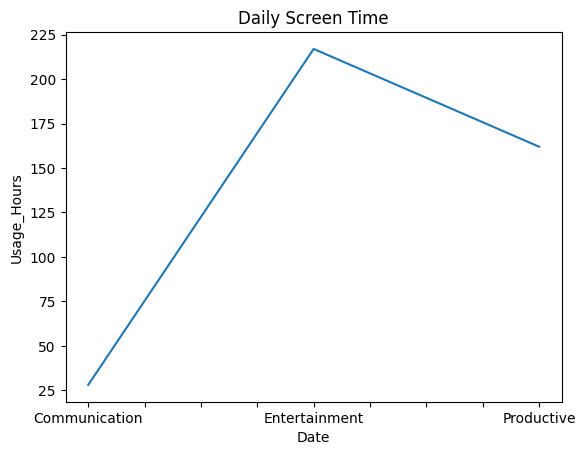

In [ ]:
#Visualizations
#Daily Screen Time
daily_usage.plot(kind='line')
plt.title('Daily Screen Time')
plt.xlabel('Date')
plt.ylabel('Usage_Hours')
plt.show()

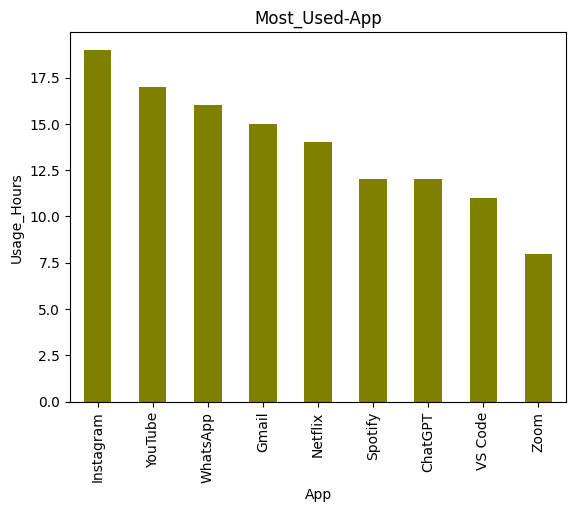

In [ ]:
#Most Used App
most_used_App=df['App'].value_counts()
most_used_App.plot(kind='bar',color='olive')
plt.title('Most_Used-App')
plt.xlabel('App')
plt.ylabel('Usage_Hours')
plt.show()

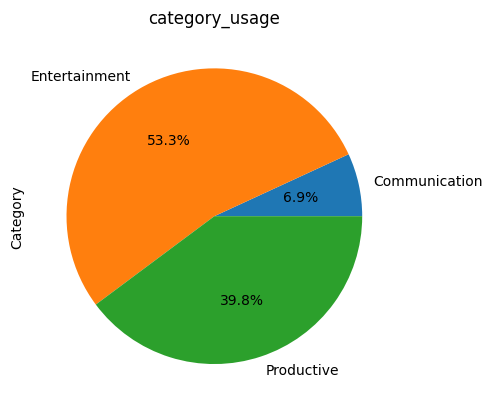

In [ ]:
#Category_Usage
Category_Usage=df.groupby('Category')['Usage_Hours'].sum()
Category_Usage.plot(kind='pie',autopct='%1.1f%%')
plt.title('category_usage')
plt.ylabel('Category')
plt.show()

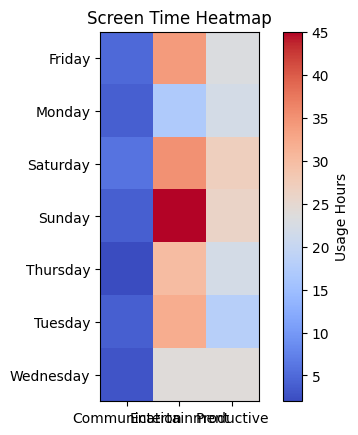

In [ ]:
#Screen Time Heatmap
heatmap_data=df.pivot_table(
    values='Usage_Hours',
    index='Day',
    columns='Category',
    aggfunc='sum'
    )
plt.imshow(heatmap_data,cmap='coolwarm')
plt.colorbar(label='Usage Hours')
plt.xticks(
    range(len(heatmap_data.columns)),heatmap_data.columns
)
plt.yticks(
    range(len(heatmap_data.index)),heatmap_data.index
)

plt.title('Screen Time Heatmap')
plt.show()